# CHSH Game: Quantum vs Classical Correlation

**The CHSH Game** demonstrates how quantum entanglement produces stronger-than-classical correlations.

### Rules
- Referee sends random bits $x$ to Alice and $y$ to Bob.
- Alice outputs $a$, Bob outputs $b$.
- **Win condition**: $a \oplus b = x \land y$

### Bounds
- Classical optimal: $P(win) = 0.75$  ($|S| \leq 2$)
- Quantum optimal: $P(win) = \cos^2(\pi/8) \approx 0.854$  ($|S| \leq 2\sqrt{2}$)

In [6]:
pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.0 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer

print("All imports OK")

All imports OK


---
## 1. Classical Strategy

The best deterministic strategy: both always output $0$.

- Wins when $(x,y) \in \{(0,0), (0,1), (1,0)\}$ → $3/4$ of the time.
- Loses only when $(x,y) = (1,1)$.

In [8]:
def classical_full_stats(trials: int = 200_000):
    rng = np.random.default_rng()
    outcomes = {(x, y): {"00": 0, "01": 0, "10": 0, "11": 0}
                for x in (0, 1) for y in (0, 1)}
    for _ in range(trials):
        x = int(rng.integers(0, 2))
        y = int(rng.integers(0, 2))
        outcomes[(x, y)]["00"] += 1  # a=0, b=0 always
    return outcomes

cls_out = classical_full_stats(200_000)
print("Classical simulation complete")

Classical simulation complete


---
## 2. Quantum Strategy

Alice and Bob share a Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$.

They measure in rotated bases depending on their inputs:

| Input | Alice rotation | Bob rotation |
|-------|---------------|-------------|
| $x=0$ | $0$ (Z-basis) | — |
| $x=1$ | $-\pi/2$ (X-basis) | — |
| $y=0$ | — | $-\pi/4$ |
| $y=1$ | — | $\pi/4$ |

In [9]:
def quantum_circuit(x: int, y: int) -> QuantumCircuit:
    qr = QuantumRegister(2, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.cx(qr[0], qr[1])

    if x == 0:
        qc.ry(0, qr[0])
    else:
        qc.ry(-np.pi / 2, qr[0])

    if y == 0:
        qc.ry(-np.pi / 4, qr[1])
    else:
        qc.ry(np.pi / 4, qr[1])

    qc.measure(qr[0], cr[0])
    qc.measure(qr[1], cr[1])
    return qc


def quantum_full_stats(trials: int = 200_000):
    backend = Aer.get_backend("qasm_simulator")
    shots = max(1, trials // 4)
    outcomes = {(x, y): {"00": 0, "01": 0, "10": 0, "11": 0}
                for x in (0, 1) for y in (0, 1)}

    for x in (0, 1):
        for y in (0, 1):
            qc = quantum_circuit(x, y)
            result = backend.run(qc, shots=shots).result()
            counts = result.get_counts()

            for bitstring, count in counts.items():
                a = int(bitstring[1])
                b = int(bitstring[0])
                outcomes[(x, y)][f"{a}{b}"] += count

    return outcomes


qnt_out = quantum_full_stats(200_000)
print("Quantum simulation complete")

Quantum simulation complete


---
## 3. Evaluation Matrix

The evaluation matrix shows the distribution of Alice and Bob's outputs $(a,b)$ for each possible input pair $(x,y)$.

In [10]:
def print_evaluation_matrix(outcomes, label):
    print(f"\n  {label}")
    print(f"  {'-' * 40}")
    print(f"  (x,y) │  00     01     10     11   │ P(win) ")
    print(f"  ──────┼─────────────────────────────┼────────")
    total_wins = 0
    total_all = 0
    for x in (0, 1):
        for y in (0, 1):
            dist = outcomes[(x, y)]
            s = sum(dist.values())
            wins = dist["00"] + dist["11"] if (x & y) == 0 else dist["01"] + dist["10"]
            pw = wins / s if s > 0 else 0
            total_wins += wins
            total_all += s
            print(f"  ({x},{y})  │ {dist['00']/s:.4f}  {dist['01']/s:.4f}  "
                  f"{dist['10']/s:.4f}  {dist['11']/s:.4f}  │ {pw:.4f}")
    print(f"  ──────┴─────────────────────────────┴────────")
    print(f"  Overall P(win) = {total_wins / total_all:.4f}")


print_evaluation_matrix(cls_out, "CLASSICAL")
print_evaluation_matrix(qnt_out, "QUANTUM")


  CLASSICAL
  ----------------------------------------
  (x,y) │  00     01     10     11   │ P(win) 
  ──────┼─────────────────────────────┼────────
  (0,0)  │ 1.0000  0.0000  0.0000  0.0000  │ 1.0000
  (0,1)  │ 1.0000  0.0000  0.0000  0.0000  │ 1.0000
  (1,0)  │ 1.0000  0.0000  0.0000  0.0000  │ 1.0000
  (1,1)  │ 1.0000  0.0000  0.0000  0.0000  │ 0.0000
  ──────┴─────────────────────────────┴────────
  Overall P(win) = 0.7523

  QUANTUM
  ----------------------------------------
  (x,y) │  00     01     10     11   │ P(win) 
  ──────┼─────────────────────────────┼────────
  (0,0)  │ 0.4291  0.0727  0.0736  0.4246  │ 0.8537
  (0,1)  │ 0.4289  0.0734  0.0727  0.4249  │ 0.8538
  (1,0)  │ 0.4215  0.0744  0.0729  0.4311  │ 0.8526
  (1,1)  │ 0.0742  0.4282  0.4241  0.0735  │ 0.8523
  ──────┴─────────────────────────────┴────────
  Overall P(win) = 0.8531


---
## 4. Correlation Strength (CHSH Value)

The correlation for each input pair:
$$E[A_x B_y] = P(a=b) - P(a \neq b)$$

The CHSH value $S$ combines them:
$$S = E[A_0 B_0] + E[A_0 B_1] + E[A_1 B_0] - E[A_1 B_1]$$

| Bound | Value |
|-------|-------|
| Classical (Bell's theorem) | $|S| \leq 2$ |
| Quantum (Tsirelson's bound) | $|S| \leq 2\sqrt{2} \approx 2.828$ |

In [11]:
def chsh_correlation(outcomes):
    E = {}
    for (x, y), dist in outcomes.items():
        total = sum(dist.values())
        p_same = (dist["00"] + dist["11"]) / total
        p_diff = (dist["01"] + dist["10"]) / total
        E[(x, y)] = p_same - p_diff
    S = E[(0, 0)] + E[(0, 1)] + E[(1, 0)] - E[(1, 1)]
    return E, S


cls_E, cls_S = chsh_correlation(cls_out)
qnt_E, qnt_S = chsh_correlation(qnt_out)

print(f"{'Input':>8}  {'Classical E':>12}  {'Quantum E':>12}")
print(f"{'─' * 34}")
for xy in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    print(f"  ({xy[0]},{xy[1]})     {cls_E[xy]:>+10.4f}     {qnt_E[xy]:>+10.4f}")
print()
print(f"CHSH S (classical): {cls_S:+.4f}  (bound: |S| ≤ 2)")
print(f"CHSH S (quantum):   {qnt_S:+.4f}  (bound: |S| ≤ 2√2 ≈ 2.828)")

   Input   Classical E     Quantum E
──────────────────────────────────
  (0,0)        +1.0000        +0.7073
  (0,1)        +1.0000        +0.7077
  (1,0)        +1.0000        +0.7053
  (1,1)        +1.0000        -0.7047

CHSH S (classical): +2.0000  (bound: |S| ≤ 2)
CHSH S (quantum):   +2.8250  (bound: |S| ≤ 2√2 ≈ 2.828)


---
## 5. Visual Comparison

Four-panel figure: correlation bars, heatmap, overall metrics, and per-input win rates.

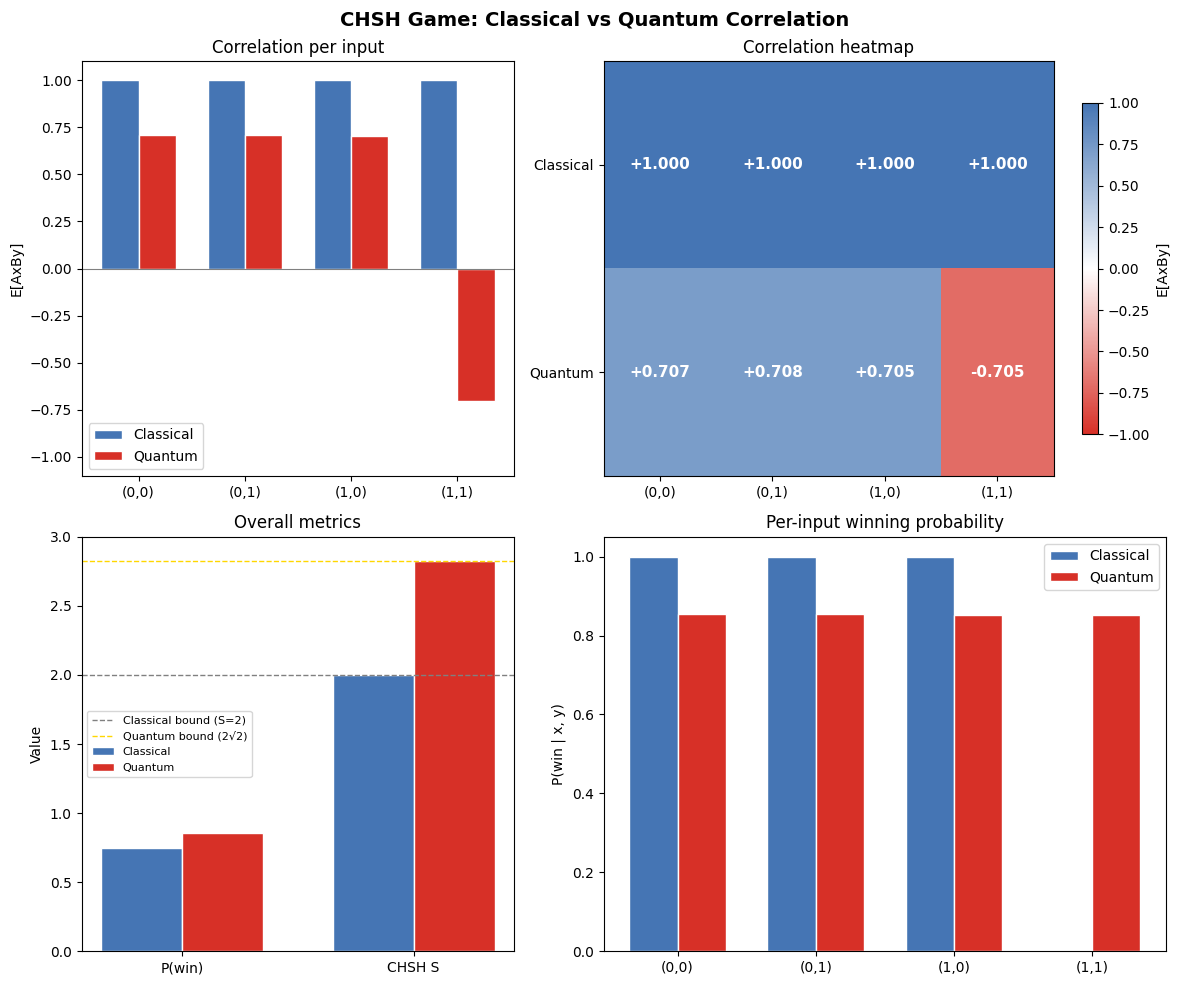

In [12]:
def plot_results(cls_E, cls_S, qnt_E, qnt_S, cls_pwin, qnt_pwin):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), width_ratios=[1, 1.3])
    fig.suptitle("CHSH Game: Classical vs Quantum Correlation", fontsize=14, fontweight="bold")

    cmap = LinearSegmentedColormap.from_list("rdbu", ["#d73027", "white", "#4575b4"], N=256)
    inputs = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]
    xpos = np.arange(4)
    cls_vals = [cls_E[(0, 0)], cls_E[(0, 1)], cls_E[(1, 0)], cls_E[(1, 1)]]
    qnt_vals = [qnt_E[(0, 0)], qnt_E[(0, 1)], qnt_E[(1, 0)], qnt_E[(1, 1)]]
    w = 0.35

    # Top-left: E[AxBy] bar chart
    ax = axes[0, 0]
    ax.bar(xpos - w / 2, cls_vals, w, label="Classical", color="#4575b4", edgecolor="white")
    ax.bar(xpos + w / 2, qnt_vals, w, label="Quantum", color="#d73027", edgecolor="white")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(xpos)
    ax.set_xticklabels(inputs)
    ax.set_ylabel("E[AxBy]")
    ax.set_title("Correlation per input")
    ax.legend()
    ax.set_ylim(-1.1, 1.1)

    # Top-right: heatmap
    ax = axes[0, 1]
    heat_data = np.array([cls_vals, qnt_vals])
    im = ax.imshow(heat_data, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(4))
    ax.set_xticklabels(inputs)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Classical", "Quantum"])
    for i in range(2):
        for j in range(4):
            ax.text(j, i, f"{heat_data[i, j]:+.3f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if abs(heat_data[i, j]) > 0.5 else "black")
    ax.set_title("Correlation heatmap")
    plt.colorbar(im, ax=ax, label="E[AxBy]", shrink=0.8)

    # Bottom-left: overall metrics
    ax = axes[1, 0]
    cls_met = [cls_pwin, cls_S]
    qnt_met = [qnt_pwin, qnt_S]
    ax.bar([0, 1], cls_met, w, label="Classical", color="#4575b4", edgecolor="white")
    ax.bar([0.35, 1.35], qnt_met, w, label="Quantum", color="#d73027", edgecolor="white")
    ax.axhline(2, color="gray", linestyle="--", linewidth=1, label="Classical bound (S=2)")
    ax.axhline(2 * np.sqrt(2), color="gold", linestyle="--", linewidth=1, label="Quantum bound (2√2)")
    ax.set_xticks([0.175, 1.175])
    ax.set_xticklabels(["P(win)", "CHSH S"])
    ax.set_ylabel("Value")
    ax.set_title("Overall metrics")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 3)

    # Bottom-right: per-input P(win)
    ax = axes[1, 1]
    cls_winrate = [1.0, 1.0, 1.0, 0.0]
    qnt_winrate = []
    for (x, y) in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        E = qnt_E[(x, y)]
        qnt_winrate.append((1 + E) / 2 if (x & y) == 0 else (1 - E) / 2)
    ax.bar(xpos - w / 2, cls_winrate, w, label="Classical", color="#4575b4", edgecolor="white")
    ax.bar(xpos + w / 2, qnt_winrate, w, label="Quantum", color="#d73027", edgecolor="white")
    ax.set_xticks(xpos)
    ax.set_xticklabels(inputs)
    ax.set_ylabel("P(win | x, y)")
    ax.set_title("Per-input winning probability")
    ax.legend()
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    return fig


cls_pwin = 0.75  # theoretical
qnt_pwin = sum(sum(v.values()) for v in qnt_out.values())
qnt_wins = sum(qnt_out[(x, y)]["00"] + qnt_out[(x, y)]["11"]
               if (x & y) == 0 else
               qnt_out[(x, y)]["01"] + qnt_out[(x, y)]["10"]
               for x in (0, 1) for y in (0, 1))
qnt_total = sum(sum(v.values()) for v in qnt_out.values())

fig = plot_results(cls_E, cls_S, qnt_E, qnt_S, cls_pwin, qnt_wins / qnt_total)
plt.show()

---
## 6. Summary

| Metric | Classical | Quantum | Bound |
|--------|-----------|---------|-------|
| P(win) | 0.7500 | ~0.854 | 0.75 / 0.854 |
| CHSH S | 2.0000 | ~2.828 | 2 / 2√2 |
| Violates LHVT? | No | **Yes** | — |

**Key takeaway**: Quantum entanglement produces correlations stronger than any possible classical (local hidden variable) theory. The CHSH value $S = 2.82$ exceeds the classical bound of $2$, violating Bell's inequality and demonstrating quantum advantage.